# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import shap
import dcor             # to find distance correlation
import os
import joblib           # to store the outputs and remove re-run problem.
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, AdaBoostClassifier
from sklearn.utils.class_weight import compute_class_weight # perform class weights to handle imbalanced data.
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay, precision_recall_curve,
    make_scorer, fbeta_score
)
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from scipy.stats import spearmanr   # check correlation using spearman correlation.

from IPython.display import clear_output # for no screen skip in case of heavy html rendering
clear_output()

print('All libraries imported.')

All libraries imported.


# 2. Loading Data 

In [2]:
df = pd.read_csv('CVD_Dataset.csv')
pd.set_option('display.max_columns', None)

display(df.head())
df.shape

,Age,Gender,Region,Urban_Rural,Socioeconomic_Status,Occupation,Diet_Type,Junk_Food_Frequency,Physical_Activity_Level,Daily_Steps,Screen_Time_Hours,Sleep_Hours,Stress_Level,Smoking_Status,Alcohol_Consumption,Family_History_CVD,Diabetes,Hypertension,PCOS,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Resting_Heart_Rate,Fasting_Blood_Sugar,HbA1c,Total_Cholesterol,LDL,HDL,Triglycerides,Air_Pollution_Exposure,Work_Stress_Type,CVD_Risk,Metabolic Syndrome,Cardio_Risk_Score,Pulse_Pressure,Sleep_Risk,High_Screen_Time
0,24,Female,South,Urban,Upper-Middle,Unemployed,Eggetarian,5.0,Moderate,5482.0,2.3,6.4,7.0,Never,Low,0,0,0,0,22.3,138.0,74.0,66.0,92.2,5.0,201.5000,118.7,55.7,135.5,Moderate,Physical,0,0,3,64.0,0,0
1,37,Female,Central,Rural,Lower-Middle,Small_Business,Vegetarian,7.0,Low,2042.0,6.4,5.9,5.0,Never,Low,0,0,0,0,23.5,122.0,82.0,67.0,83.8,4.4,256.9755,164.2,56.4,195.3,Low,Shift-based,0,0,3,40.0,1,0
2,32,Female,Central,Rural,Lower-Middle,Labor_Worker,Non-Vegetarian,0.0,Moderate,8385.0,4.4,7.9,2.0,Never,Moderate,0,0,0,0,26.4,106.0,82.0,56.0,101.2,5.8,175.4000,123.6,31.1,103.2,Low,Physical,0,0,2,24.0,0,0
3,28,Male,Central,Rural,Middle,Labor_Worker,Eggetarian,4.0,High,13914.0,3.2,6.6,6.0,Occasional,Low,0,0,0,0,20.9,118.0,77.0,68.0,89.4,5.3,175.0000,83.0,55.0,184.8,Low,Physical,0,0,2,41.0,0,0
4,25,Female,North,Rural,Lower,Small_Business,Vegetarian,1.0,Low,4076.0,0.3,6.3,6.0,Never,Low,0,0,0,0,28.8,131.0,92.0,77.0,101.7,5.8,188.2000,140.6,21.6,129.6,Low,Physical,0,0,3,39.0,0,0


(180000, 37)

# 3. Explore the Dataset

In [3]:
print('\n\t' + '*'*130 + '\n\t')
print('\t'*6 + 'Heart Attack Occurrence data check')
display(df['CVD_Risk'].value_counts())
print('\n\t' + '*'*130 + '\n\t')
print('\t'*7 + 'Data Information')
display(df.info())
print('\n\t' + '*'*130 + '\n\t')
print('\t'*7 + 'Integer Data Description')
display(df.describe())
print('\n\t' + '*'*130 + '\n\t')
print('\t'*7 + 'Object Data Description')
display(df.describe(include='object'))
print('\n\t' + '*'*130 + '\n\t')
print('\t'*7 + 'Check Duplicate Values')
display(df.duplicated().value_counts())
print('\n\t' + '*'*130 + '\n\t')
print('\t'*7 + '   Check Null Values')
display(df.isnull().sum().sum())
print('\n\t' + '*'*130 + '\n\t')
pd.set_option('display.max_columns', None)
print('\t'*7 + 'Count of all Data Types')
display(df.dtypes.value_counts())
print('\t'*7 + 'Count of all Data Types')
print('\n\t' + '*'*130 + '\n\t')
print('\t'*8 + 'Shape')
display(df.shape)


	**********************************************************************************************************************************
	
						Heart Attack Occurrence data check


CVD_Risk
0    158930
1     21070
Name: count, dtype: int64


	**********************************************************************************************************************************
	
							Data Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 37 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       180000 non-null  int64  
 1   Gender                    180000 non-null  object 
 2   Region                    180000 non-null  object 
 3   Urban_Rural               180000 non-null  object 
 4   Socioeconomic_Status      180000 non-null  object 
 5   Occupation                180000 non-null  object 
 6   Diet_Type                 180000 non-null  object 
 7   Junk_Food_Frequency       180000 non-null  float64
 8   Physical_Activity_Level   180000 non-null  object 
 9   Daily_Steps               180000 non-null  float64
 10  Screen_Time_Hours         180000 non-null  float64
 1

None


	**********************************************************************************************************************************
	
							Integer Data Description


,Age,Junk_Food_Frequency,Daily_Steps,Screen_Time_Hours,Sleep_Hours,Stress_Level,Family_History_CVD,Diabetes,Hypertension,PCOS,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Resting_Heart_Rate,Fasting_Blood_Sugar,HbA1c,Total_Cholesterol,LDL,HDL,Triglycerides,CVD_Risk,Metabolic Syndrome,Cardio_Risk_Score,Pulse_Pressure,Sleep_Risk,High_Screen_Time
count,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000
mean,29.017778,2.672556,8845.513488,4.819379,6.232866,5.907983,0.149917,0.112250,0.127761,0.048717,24.624290,126.134172,81.853028,71.255183,96.671233,5.456976,187.064722,112.563807,47.215553,136.404745,0.117056,0.166383,2.480911,44.284383,0.411000,0.130556
std,6.635673,2.103319,5208.308512,2.822847,1.145470,2.250010,0.356991,0.315675,0.333825,0.215276,3.147214,14.565317,10.305820,9.424628,23.014958,0.947714,26.935377,22.963969,11.045554,46.239911,0.321487,0.372425,1.229060,13.353940,0.492017,0.336915
min,18.000000,0.000000,2042.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,16.500000,93.000000,57.000000,47.000000,64.600000,4.100000,117.400000,53.500000,18.300000,19.624500,0.000000,0.000000,1.000000,10.000000,0.000000,0.000000
25%,23.000000,1.000000,4306.000000,2.900000,5.400000,4.000000,0.000000,0.000000,0.000000,0.000000,22.500000,116.000000,75.000000,65.000000,84.100000,5.000000,168.600000,96.800000,39.700000,104.600000,0.000000,0.000000,1.000000,35.000000,0.000000,0.000000
50%,29.000000,2.000000,7710.000000,4.400000,6.200000,6.000000,0.000000,0.000000,0.000000,0.000000,24.600000,125.000000,81.000000,71.000000,91.500000,5.300000,186.900000,112.500000,47.300000,135.500000,0.000000,0.000000,2.000000,44.000000,0.000000,0.000000
75%,35.000000,4.000000,12926.000000,6.200000,7.000000,8.000000,0.000000,0.000000,0.000000,0.000000,26.800000,135.000000,88.000000,78.000000,99.900000,5.600000,205.400000,128.200000,54.700000,167.100000,0.000000,0.000000,3.000000,53.000000,1.000000,0.000000
max,40.000000,9.000000,19862.755000,13.600000,9.200000,10.000000,1.000000,1.000000,1.000000,1.000000,32.800000,170.000000,112.000000,95.000000,200.700000,10.100000,256.975500,172.400000,75.700000,261.900000,1.000000,1.000000,5.000000,80.000000,1.000000,1.000000



	**********************************************************************************************************************************
	
							Object Data Description


,Gender,Region,Urban_Rural,Socioeconomic_Status,Occupation,Diet_Type,Physical_Activity_Level,Smoking_Status,Alcohol_Consumption,Air_Pollution_Exposure,Work_Stress_Type
count,180000,180000,180000,180000,180000,180000,180000,180000,180000,180000,180000
unique,3,5,2,5,5,3,3,3,3,3,3
top,Male,West,Rural,Lower-Middle,Labor_Worker,Non-Vegetarian,High,Never,Low,Low,Physical
freq,93271,36165,117257,59821,60066,89722,63427,138555,117005,82188,98436



	**********************************************************************************************************************************
	
							Check Duplicate Values


False    180000
Name: count, dtype: int64


	**********************************************************************************************************************************
	
							   Check Null Values


np.int64(0)


	**********************************************************************************************************************************
	
							Count of all Data Types


float64    16
object     11
int64      10
Name: count, dtype: int64

							Count of all Data Types

	**********************************************************************************************************************************
	
								Shape


(180000, 37)

# 4. EDA & Visualization before Feature Engineering

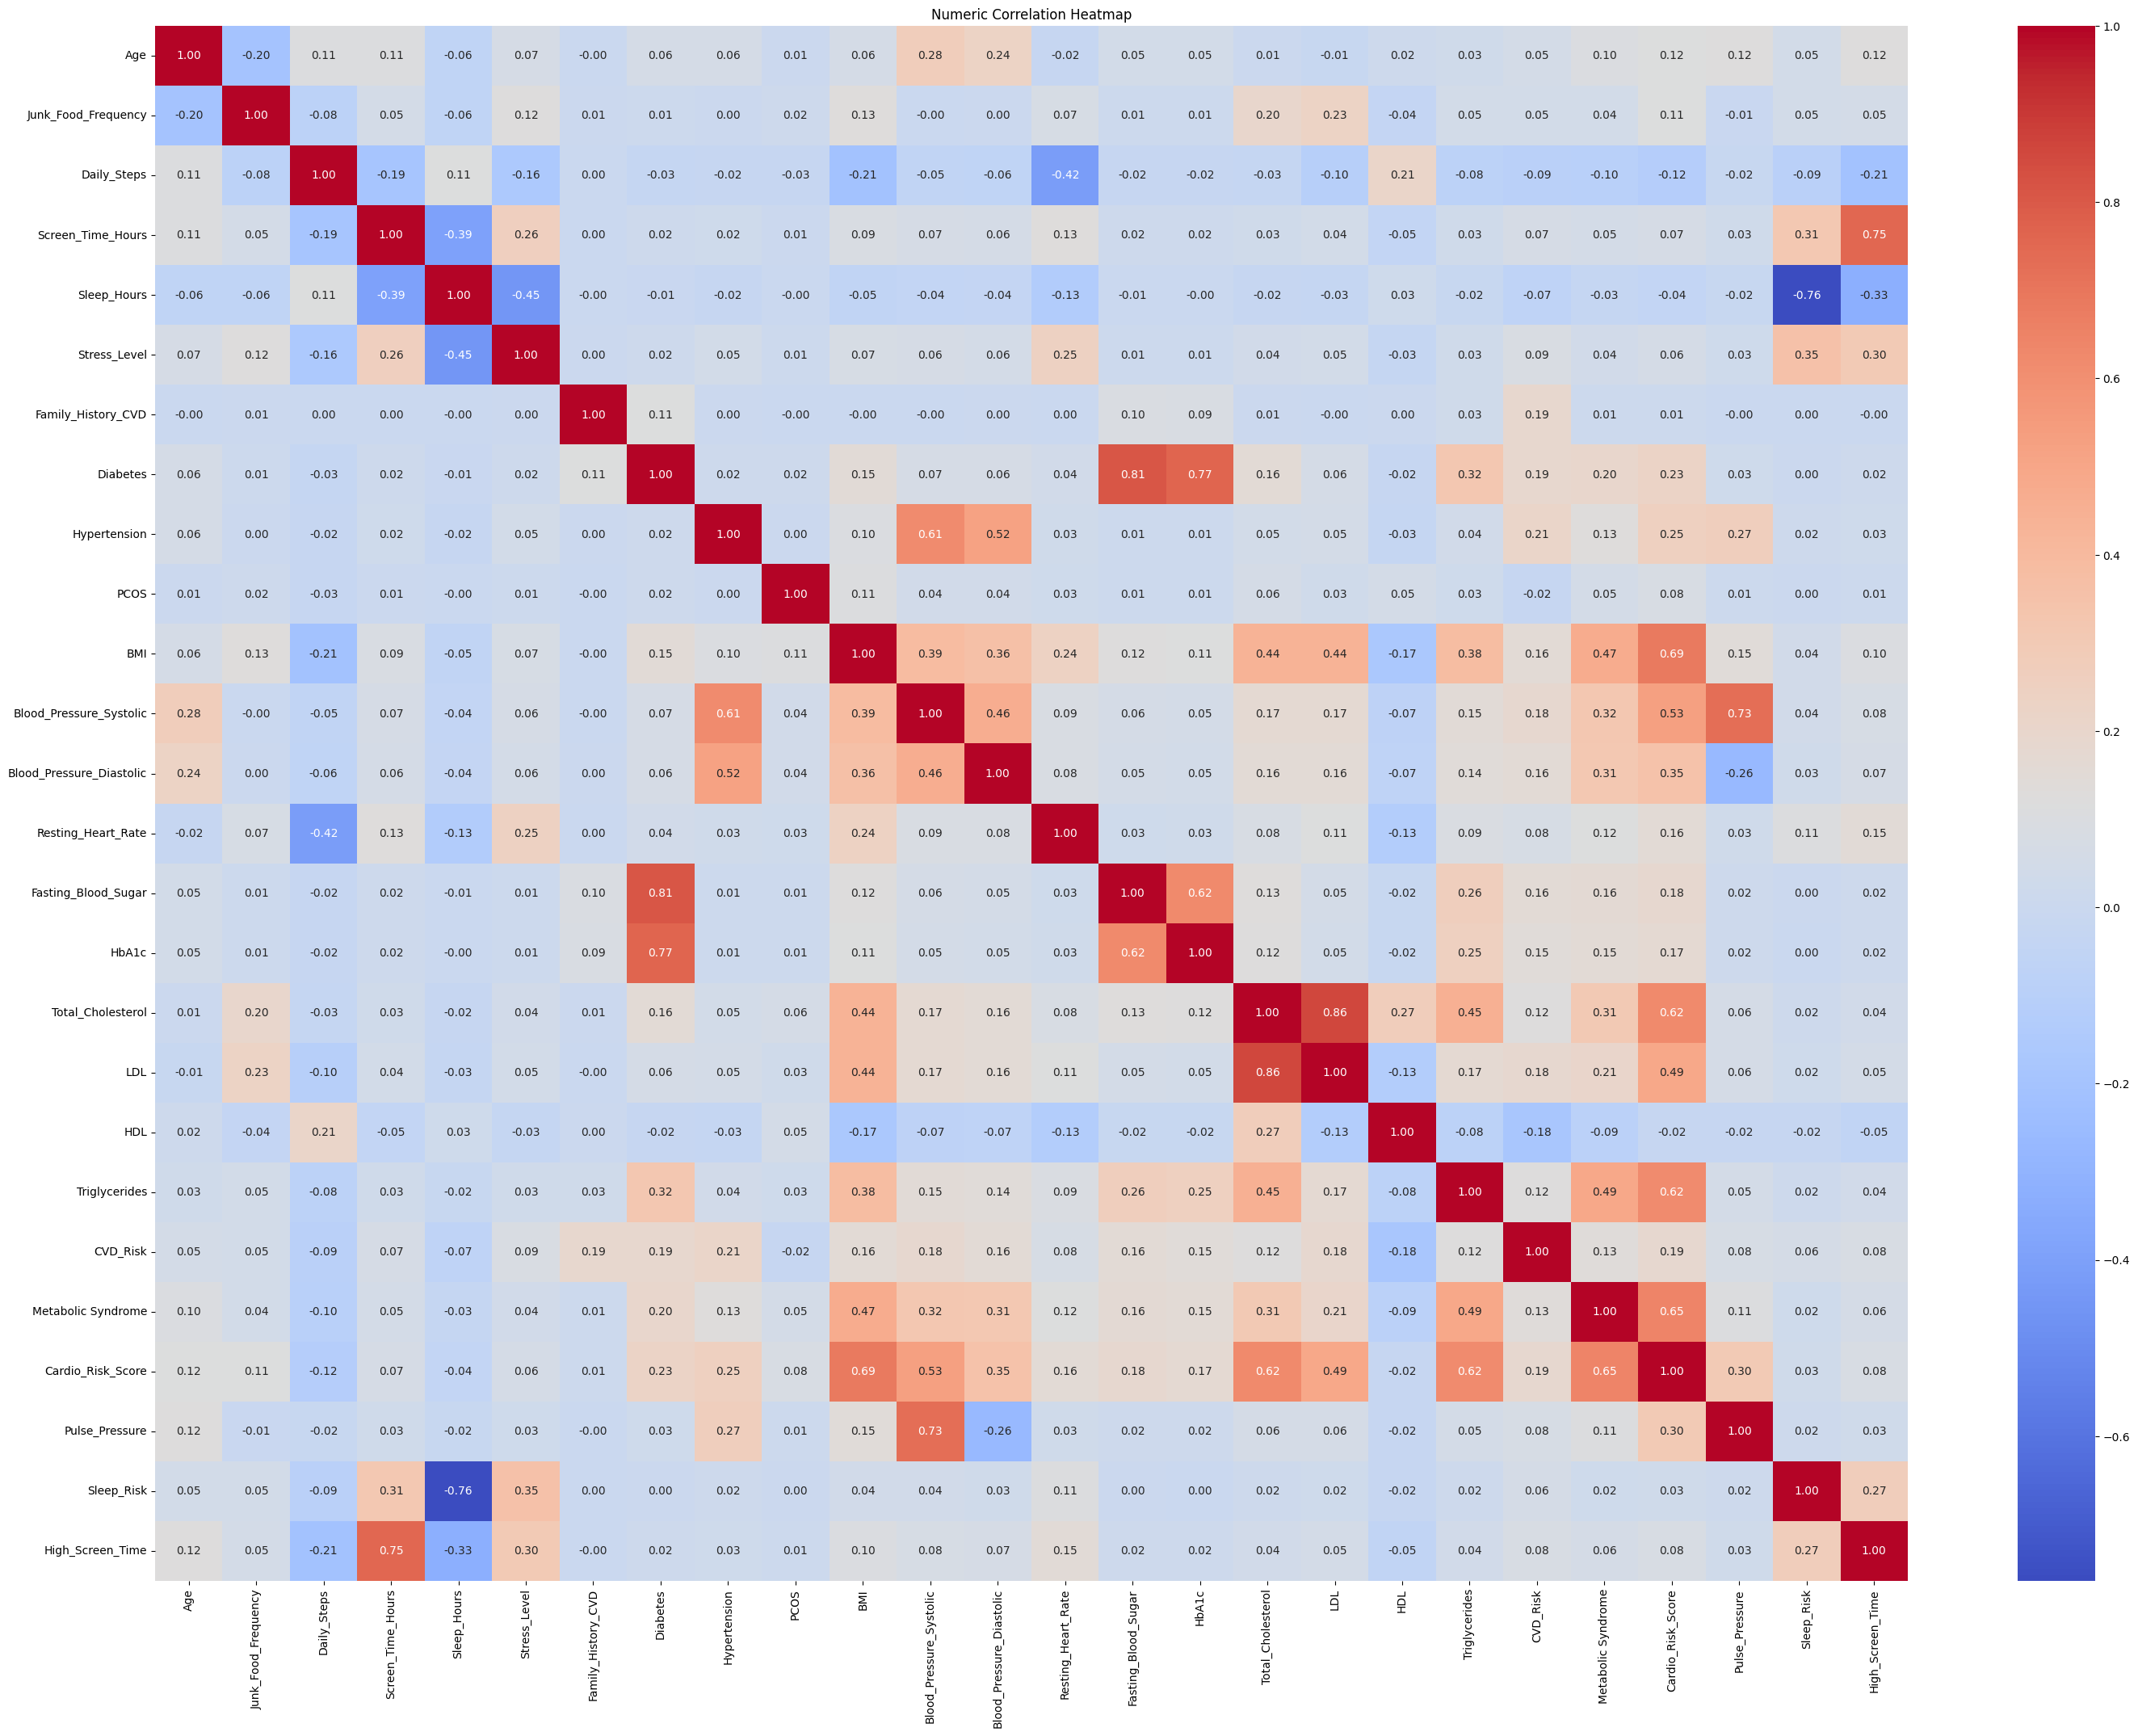

In [4]:
num_df = df.select_dtypes(include = ['int64', 'float64'])

plt.figure(figsize=(35,25))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Numeric Correlation Heatmap")
plt.show()

# 5. Preprocessing and Enhanced Feature Engineering

In [5]:
data = df.copy()

# --- Original feature: Metabolic Syndrome ---
data['Metabolic Syndrome'] = (
    (data['BMI'] >= 25).astype(int)
    + (data['Diabetes'] == 'Yes').astype(int)
    + (data['Triglycerides'] >= 150).astype(int)
    + ((data['Blood_Pressure_Systolic'] >= 130) | (data['Blood_Pressure_Diastolic'] >= 85)).astype(int)
    >= 3
).astype(int)

# ✨ NEW Feature 1: Composite Cardio Risk Score (0-8 scale)
# Combines 8 known clinical risk factors into one score
data['Cardio_Risk_Score'] = (
    (data['Total_Cholesterol'] > 200).astype(int) +
    (data['Triglycerides'] > 150).astype(int) +
    (data['Blood_Pressure_Systolic'] > 130).astype(int) +
    (data['BMI'] > 25).astype(int) +
    (data['Diabetes'] == 'Yes').astype(int) +
    (data['Hypertension'] == 'Yes').astype(int) +
    (data['Smoking_Status'].isin(['Never', 'Occasional', 'Regular'])).astype(int) +
    (data['Family_History_CVD'] == 'Yes').astype(int)
)

# ✨ NEW Feature 2: Pulse Pressure (systolic - diastolic)
data['Pulse_Pressure'] = data['Blood_Pressure_Systolic'] - data['Blood_Pressure_Diastolic']

# ✨ NEW Feature 4: Sleep risk (too little < 6hrs or too much > 9hrs)
data['Sleep_Risk'] = (
    (data['Sleep_Hours'] < 6) | (data['Sleep_Hours'] > 9)
).astype(int)

# ✨ NEW Feature 5: High screen time flag (> 8 hrs/day)
data['High_Screen_Time'] = (data['Screen_Time_Hours'] > 8).astype(int)

# --- Encode target ---
data['CVD_Risk'] = (data['CVD_Risk'] == 1).astype(int)

print(f'Features before encoding: {data.shape[1] - 1}')
print('New features added: Cardio_Risk_Score, Pulse_Pressure, Low_SpO2, Sleep_Risk, High_Screen_Time')
display(data.head())
display(data.shape)

Features before encoding: 36
New features added: Cardio_Risk_Score, Pulse_Pressure, Low_SpO2, Sleep_Risk, High_Screen_Time


,Age,Gender,Region,Urban_Rural,Socioeconomic_Status,Occupation,Diet_Type,Junk_Food_Frequency,Physical_Activity_Level,Daily_Steps,Screen_Time_Hours,Sleep_Hours,Stress_Level,Smoking_Status,Alcohol_Consumption,Family_History_CVD,Diabetes,Hypertension,PCOS,BMI,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Resting_Heart_Rate,Fasting_Blood_Sugar,HbA1c,Total_Cholesterol,LDL,HDL,Triglycerides,Air_Pollution_Exposure,Work_Stress_Type,CVD_Risk,Metabolic Syndrome,Cardio_Risk_Score,Pulse_Pressure,Sleep_Risk,High_Screen_Time
0,24,Female,South,Urban,Upper-Middle,Unemployed,Eggetarian,5.0,Moderate,5482.0,2.3,6.4,7.0,Never,Low,0,0,0,0,22.3,138.0,74.0,66.0,92.2,5.0,201.5000,118.7,55.7,135.5,Moderate,Physical,0,0,3,64.0,0,0
1,37,Female,Central,Rural,Lower-Middle,Small_Business,Vegetarian,7.0,Low,2042.0,6.4,5.9,5.0,Never,Low,0,0,0,0,23.5,122.0,82.0,67.0,83.8,4.4,256.9755,164.2,56.4,195.3,Low,Shift-based,0,0,3,40.0,1,0
2,32,Female,Central,Rural,Lower-Middle,Labor_Worker,Non-Vegetarian,0.0,Moderate,8385.0,4.4,7.9,2.0,Never,Moderate,0,0,0,0,26.4,106.0,82.0,56.0,101.2,5.8,175.4000,123.6,31.1,103.2,Low,Physical,0,0,2,24.0,0,0
3,28,Male,Central,Rural,Middle,Labor_Worker,Eggetarian,4.0,High,13914.0,3.2,6.6,6.0,Occasional,Low,0,0,0,0,20.9,118.0,77.0,68.0,89.4,5.3,175.0000,83.0,55.0,184.8,Low,Physical,0,0,2,41.0,0,0
4,25,Female,North,Rural,Lower,Small_Business,Vegetarian,1.0,Low,4076.0,0.3,6.3,6.0,Never,Low,0,0,0,0,28.8,131.0,92.0,77.0,101.7,5.8,188.2000,140.6,21.6,129.6,Low,Physical,0,0,3,39.0,0,0


(180000, 37)

## 5.1 Updating Orginal Dataset with new features

In [6]:
# Check Shape of both Datasets
print('Before Adding Features:', df.shape)
print('After Adding Features:', data.shape)
print(df.index.equals(data.index))

# Create a New Dataset which has only Features that are created.
new_features = data.drop(columns = df.columns, errors='ignore')

# concat 'new_features' dataset with 'df'
df = pd.concat([df, new_features], axis=1)

Before Adding Features: (180000, 37)
After Adding Features: (180000, 37)
True


## 5.2 Visualization after Feature Engineering

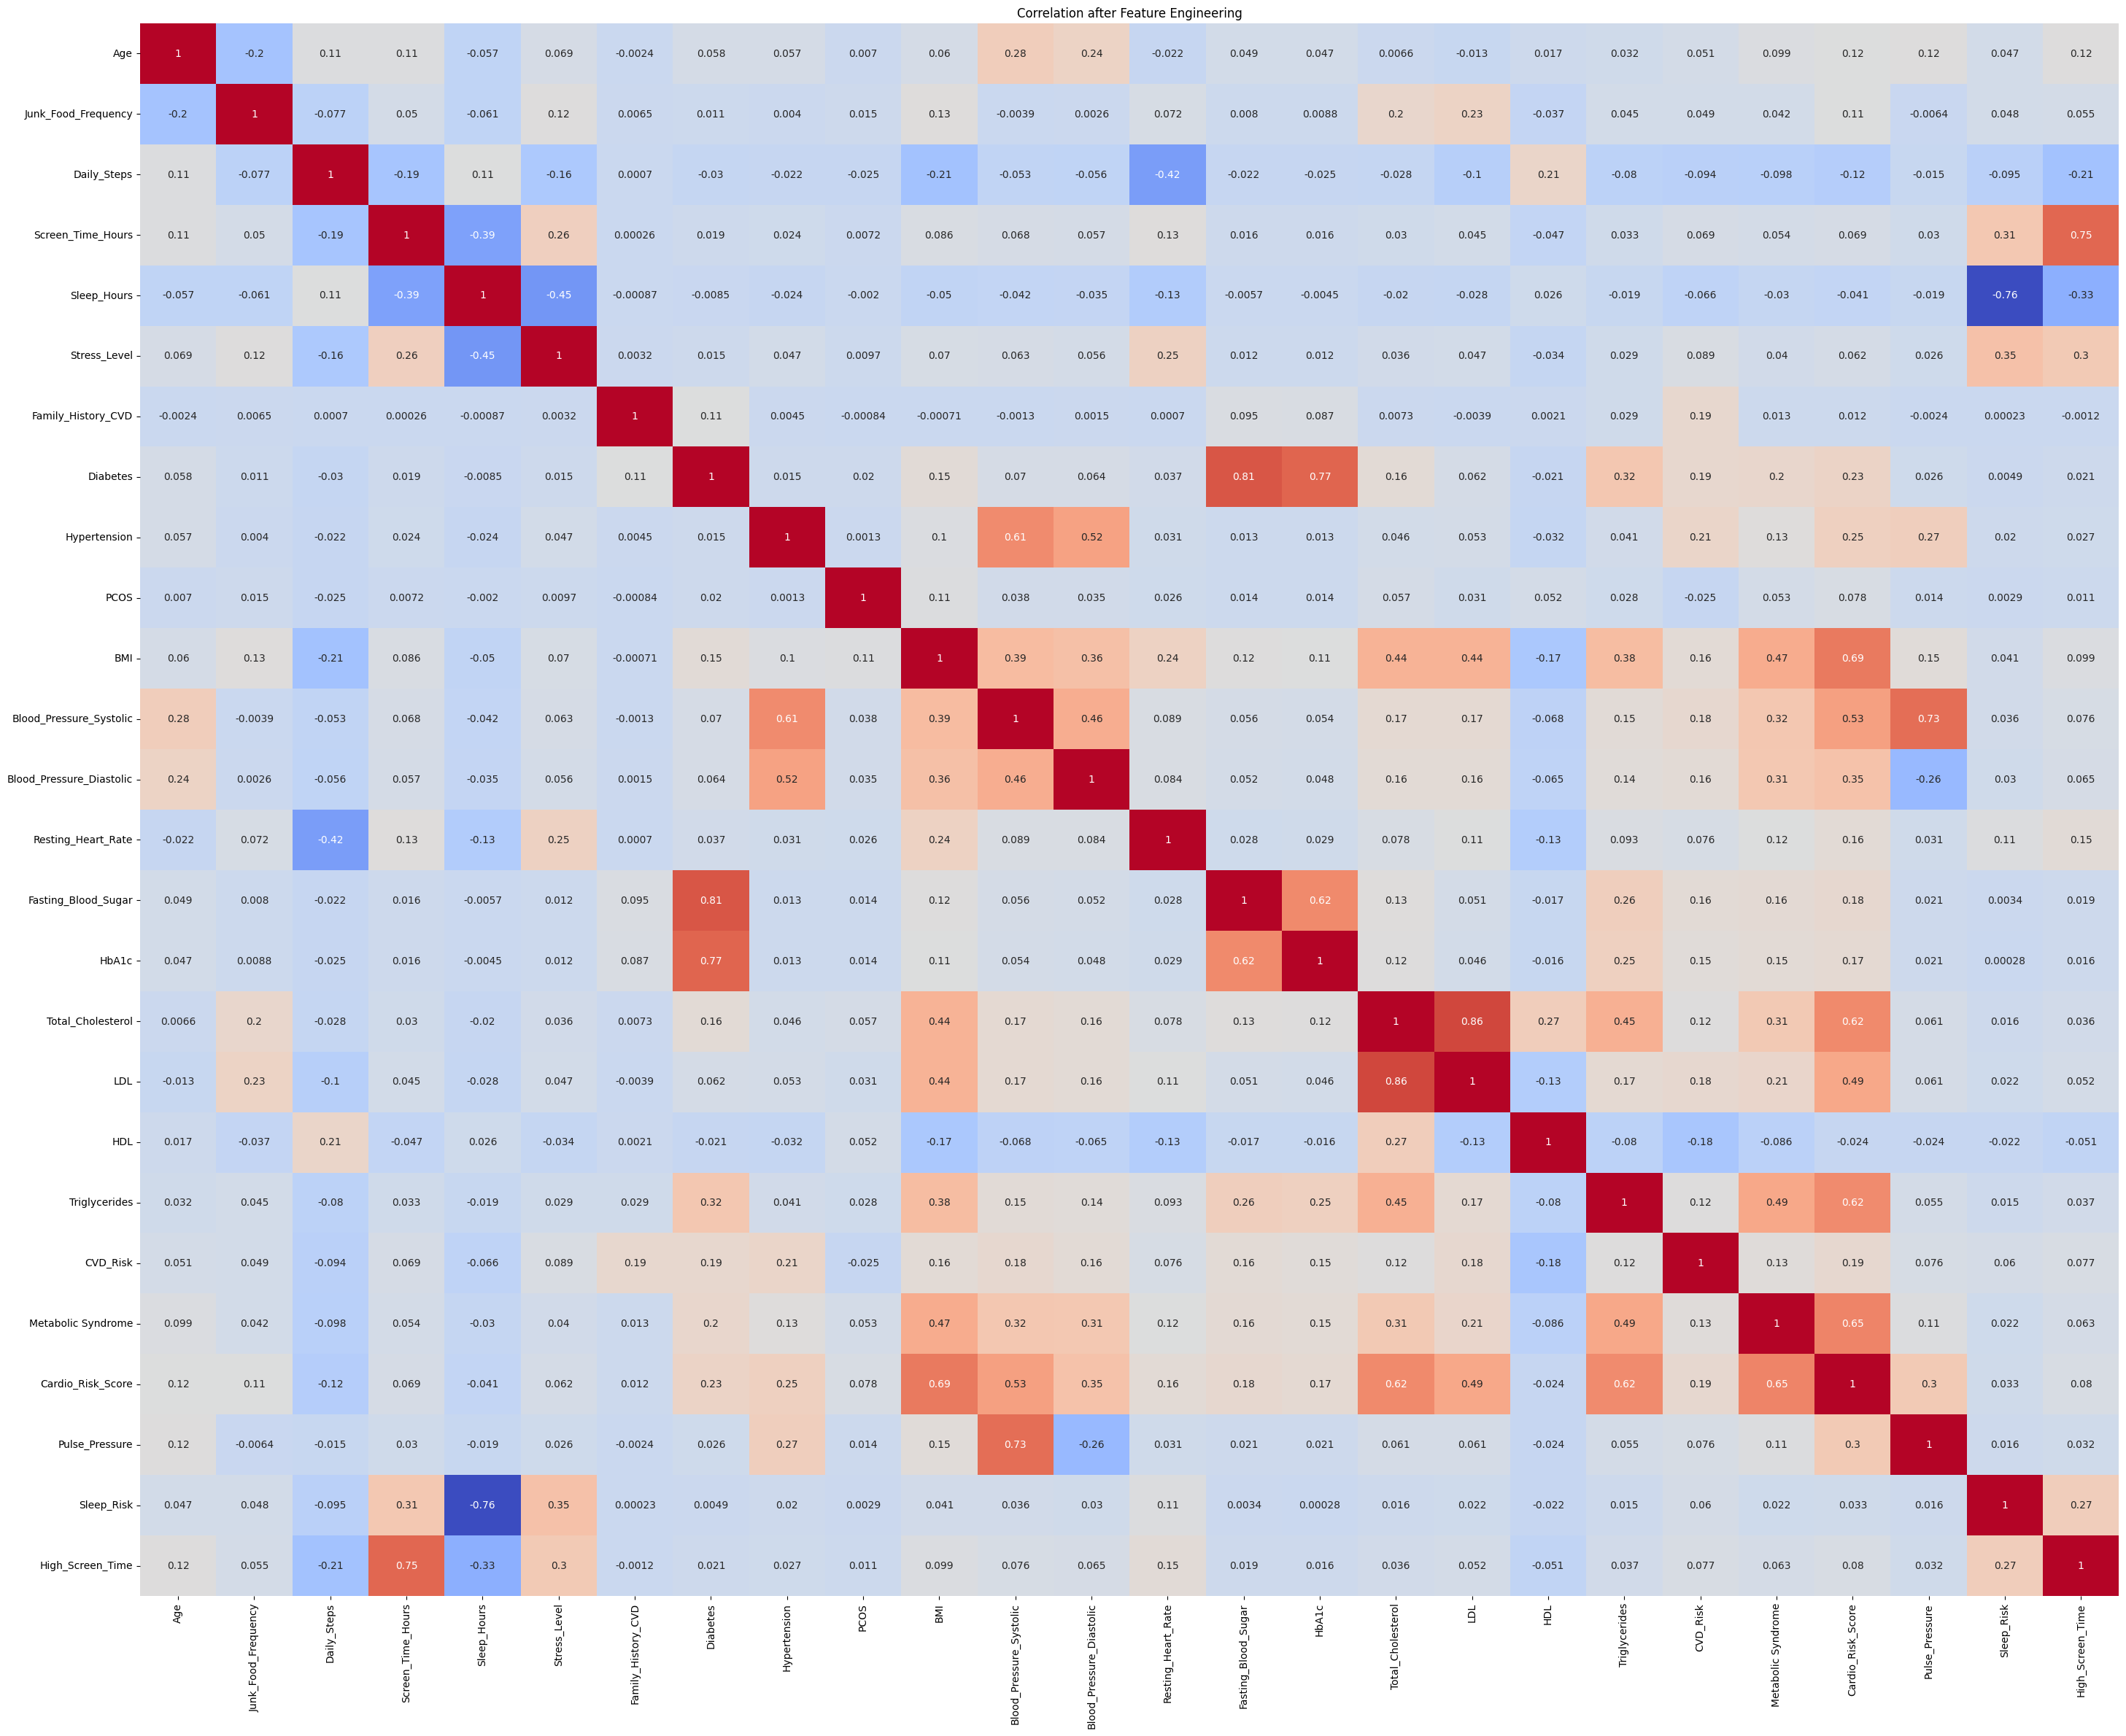

In [7]:
num_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(35, 28)) #(Horizontal-height, Vertical-height)
sns.heatmap(num_df.corr(), annot=True, fmt='.2g', cmap='coolwarm', cbar=False)
plt.title('Correlation after Feature Engineering')
plt.show()

# 5.3 Correlation Check between features

In [8]:
# Correlation with target column
num_df = df.select_dtypes(include=['int64', 'float64'])
print(num_df.corr()['CVD_Risk'].sort_values(ascending=False))

CVD_Risk                    1.000000
Hypertension                0.213437
Diabetes                    0.187762
Family_History_CVD          0.187299
Cardio_Risk_Score           0.185106
Blood_Pressure_Systolic     0.182655
LDL                         0.180767
Blood_Pressure_Diastolic    0.158750
BMI                         0.158523
Fasting_Blood_Sugar         0.156563
HbA1c                       0.145092
Metabolic Syndrome          0.132674
Total_Cholesterol           0.122436
Triglycerides               0.122040
Stress_Level                0.089029
High_Screen_Time            0.076742
Pulse_Pressure              0.076318
Resting_Heart_Rate          0.075610
Screen_Time_Hours           0.069131
Sleep_Risk                  0.060384
Age                         0.050911
Junk_Food_Frequency         0.048616
PCOS                       -0.024520
Sleep_Hours                -0.065628
Daily_Steps                -0.093543
HDL                        -0.179705
Name: CVD_Risk, dtype: float64


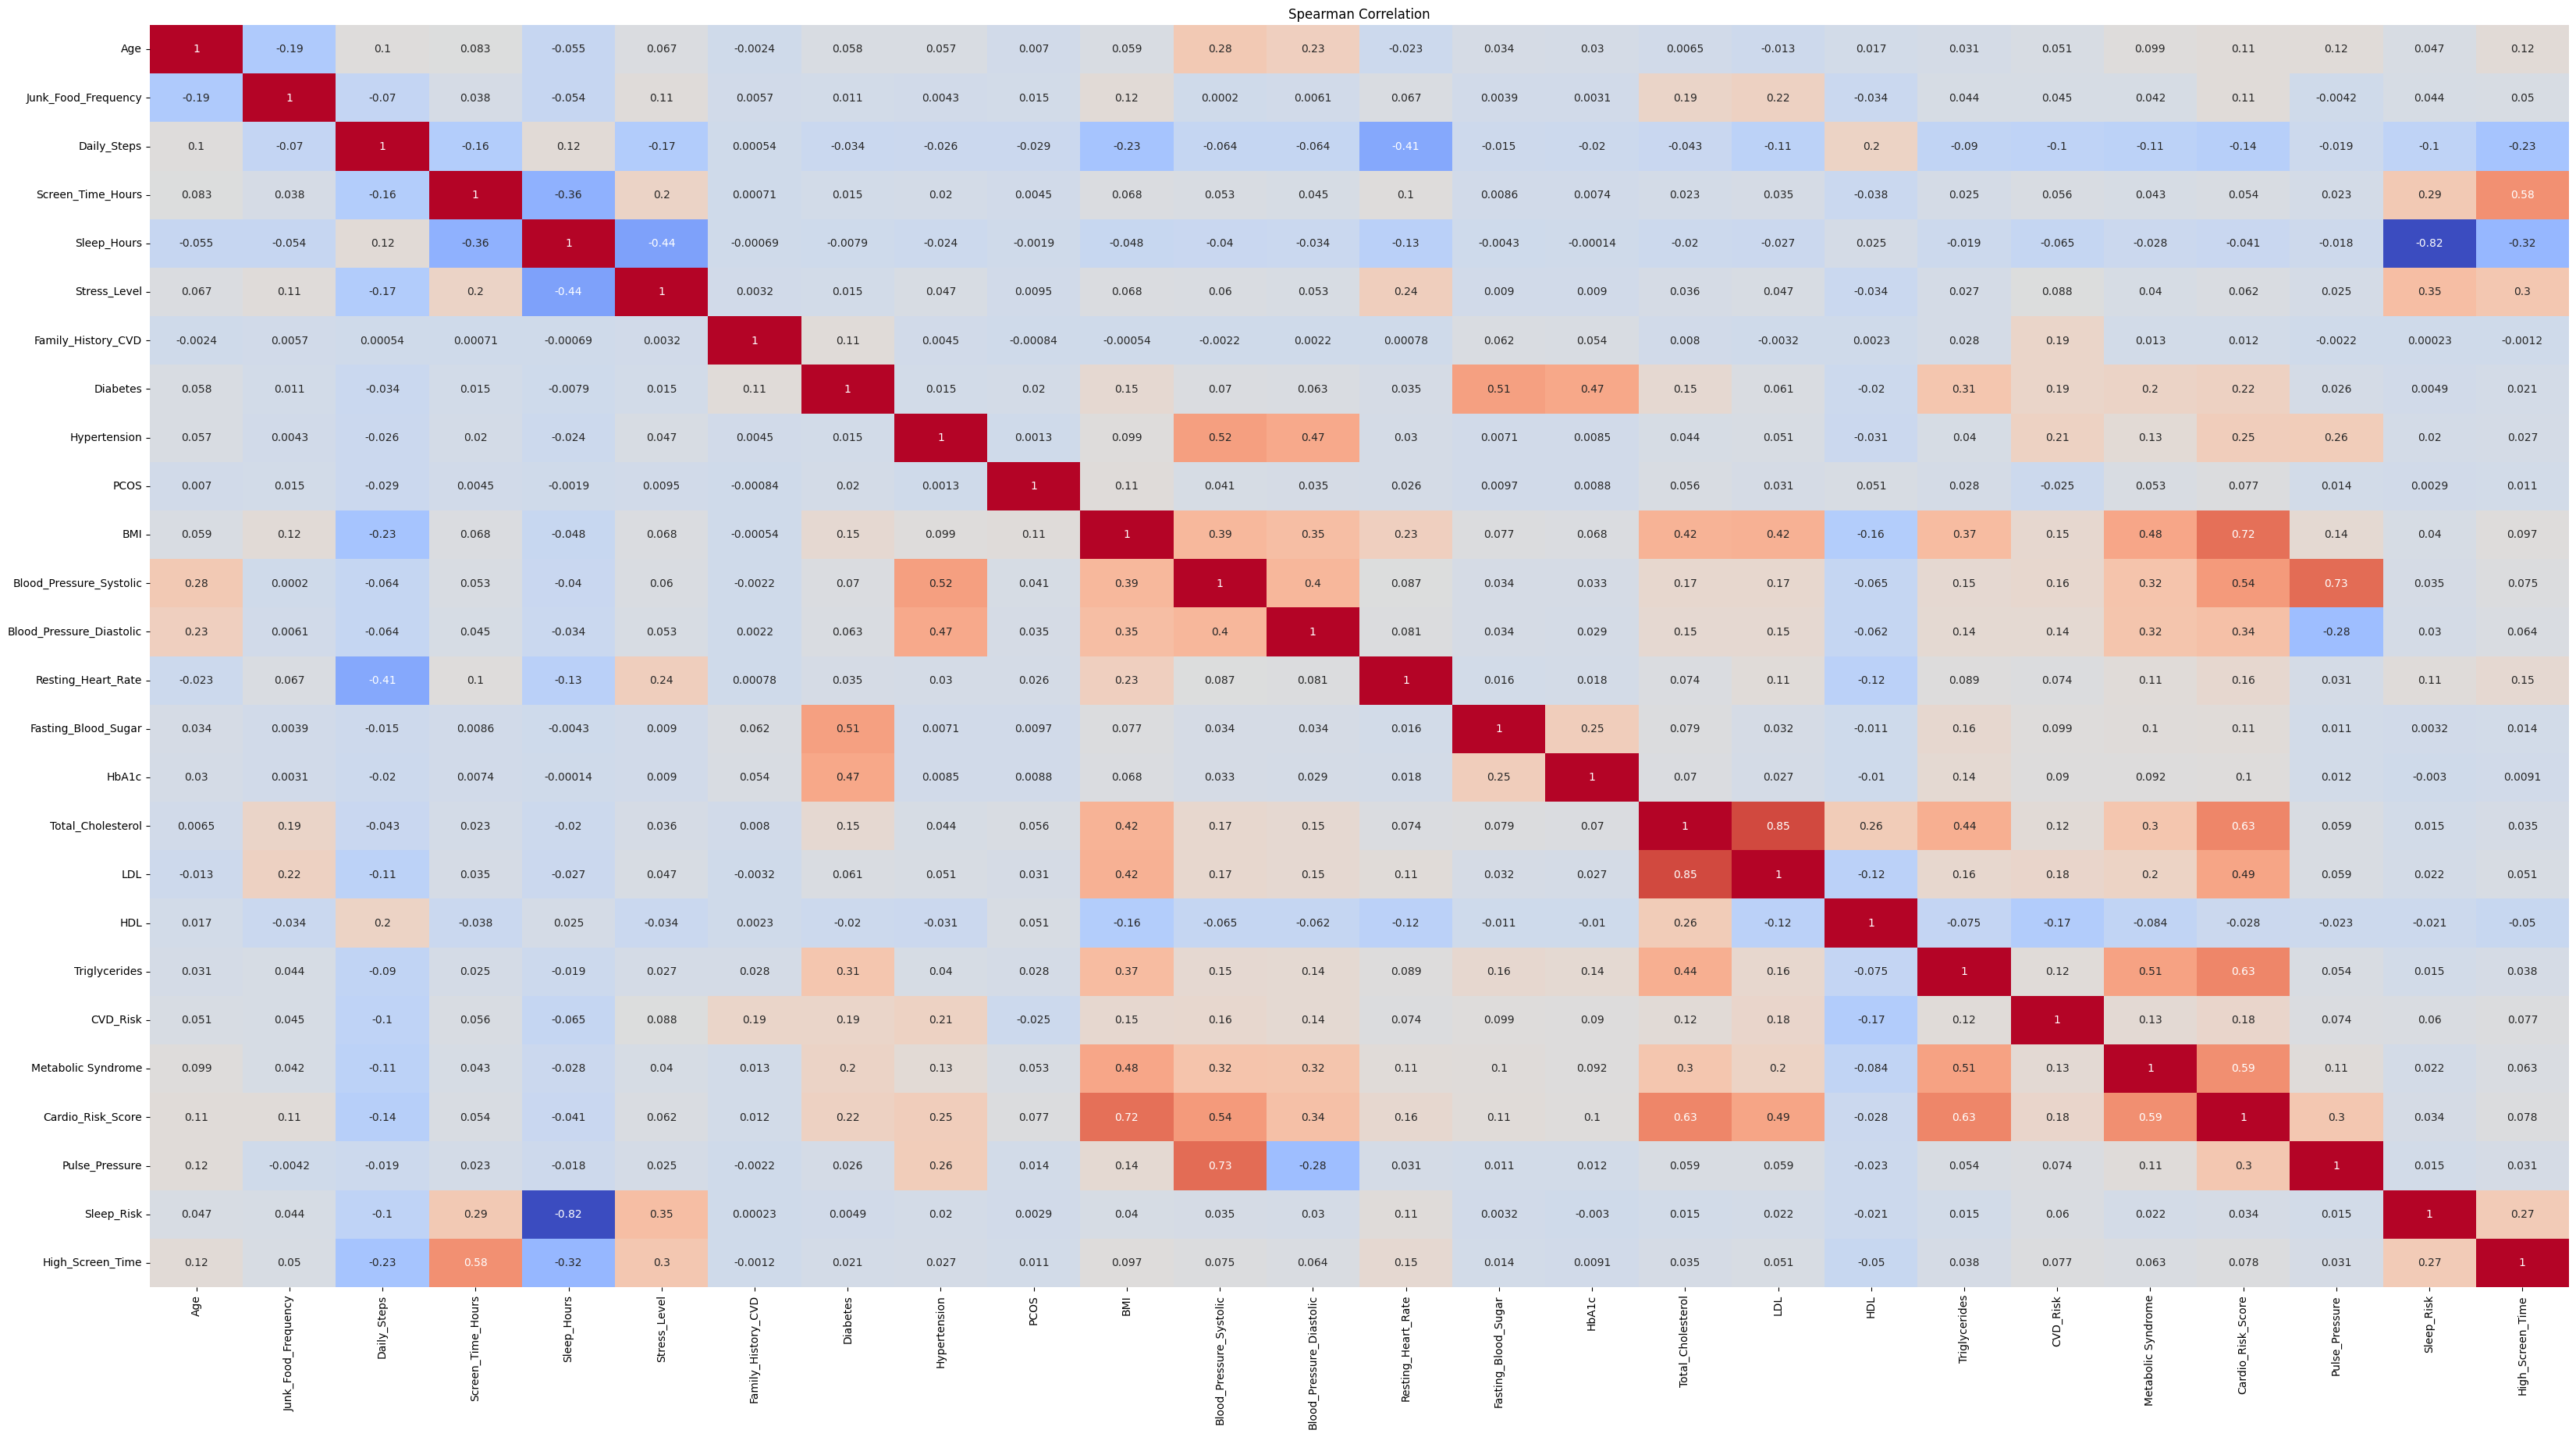

In [9]:
# Spearman Correlation
corr = num_df.corr(method='spearman')

# visualization
plt.figure(figsize=(40,21))
sns.heatmap(data=corr, annot=True, fmt='.2g', cmap='coolwarm', cbar=False)
plt.title('Spearman Correlation')
plt.show()

# 6. Train-validate-Test split

In [10]:
X = df.drop(['CVD_Risk'], axis=1)
y = df['CVD_Risk']

X_main, X_test, y_main, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_main, y_main, test_size=0.15, random_state=42, stratify=y_main
)

def print_split_info(name, X, y):
    print(f"{name}")
    print("-" * 50)
    print(f"Shape            : {X.shape}")
    print(f"Samples          : {len(X)}")
    print(f"Class Distribution (%) :")
    print(y.value_counts(normalize=True).mul(100).round(2))
    print("\n")


print_split_info("MAIN DATA", X_main, y_main)
print_split_info("TEST DATA", X_test, y_test)
print_split_info("TRAIN DATA", X_train, y_train)
print_split_info("VALIDATION DATA", X_valid, y_valid)

MAIN DATA
--------------------------------------------------
Shape            : (153000, 36)
Samples          : 153000
Class Distribution (%) :
CVD_Risk
0    88.29
1    11.71
Name: proportion, dtype: float64


TEST DATA
--------------------------------------------------
Shape            : (27000, 36)
Samples          : 27000
Class Distribution (%) :
CVD_Risk
0    88.3
1    11.7
Name: proportion, dtype: float64


TRAIN DATA
--------------------------------------------------
Shape            : (130050, 36)
Samples          : 130050
Class Distribution (%) :
CVD_Risk
0    88.29
1    11.71
Name: proportion, dtype: float64


VALIDATION DATA
--------------------------------------------------
Shape            : (22950, 36)
Samples          : 22950
Class Distribution (%) :
CVD_Risk
0    88.3
1    11.7
Name: proportion, dtype: float64




# 6.1 Handling Class Imbalance using 'Class Weights'

In [11]:
y_train.value_counts()

CVD_Risk
0    114826
1     15224
Name: count, dtype: int64

In [12]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight={0: 1.0, 1: 8.0},
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(1.0), np.int64(1): np.float64(8.0)}


# 7. outlier detection and Handling using IQR

In [13]:
# Step 1: filter continuous features
continuous_cols = [col for col in X_train.columns if (X_train[col].dtype in ['int64', 'float64'] and X_train[col].nunique() > 3)]

# Step 2: percentile bounds
lower_bound = X_train[continuous_cols].quantile(0.005)
upper_bound = X_train[continuous_cols].quantile(0.995)
    
# Step 3: Outlier count       
print("Before:")
outlier_summary = {col: ((X_train[col] < lower_bound[col]) | (X_train[col] > upper_bound[col])).sum() for col in continuous_cols}
pd.Series(outlier_summary).sort_values(ascending=False).apply(lambda x: f"{x:.3f}").to_frame(name='Outlier Count')

Before:


,Outlier Count
Daily_Steps,651.000
Triglycerides,651.000
Total_Cholesterol,651.000
Age,0.000
Fasting_Blood_Sugar,0.000
Cardio_Risk_Score,0.000
HDL,0.000
LDL,0.000
HbA1c,0.000
Resting_Heart_Rate,0.000


## 7.1 Perform Capping to handle outliers

In [14]:
# Convert all continuous columns to numeric, turning errors into NaNs
for col in continuous_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in continuous_cols:
    df[col] = df[col].clip(lower=float(lower_bound[col]), upper=float(upper_bound[col]))

print("After:")
capped = {col: ((df[col] < lower_bound[col]) | (df[col] > upper_bound[col])).sum() for col in continuous_cols}
pd.Series(capped).sort_values(ascending=False).apply(lambda x: f"{x:.3f}").to_frame(name='Outlier Count')

After:


,Outlier Count
Age,0.000
Junk_Food_Frequency,0.000
Cardio_Risk_Score,0.000
Triglycerides,0.000
HDL,0.000
LDL,0.000
Total_Cholesterol,0.000
HbA1c,0.000
Fasting_Blood_Sugar,0.000
Resting_Heart_Rate,0.000


# 8. Mutual Detection & Distance Correlation 

Loaded Successfully


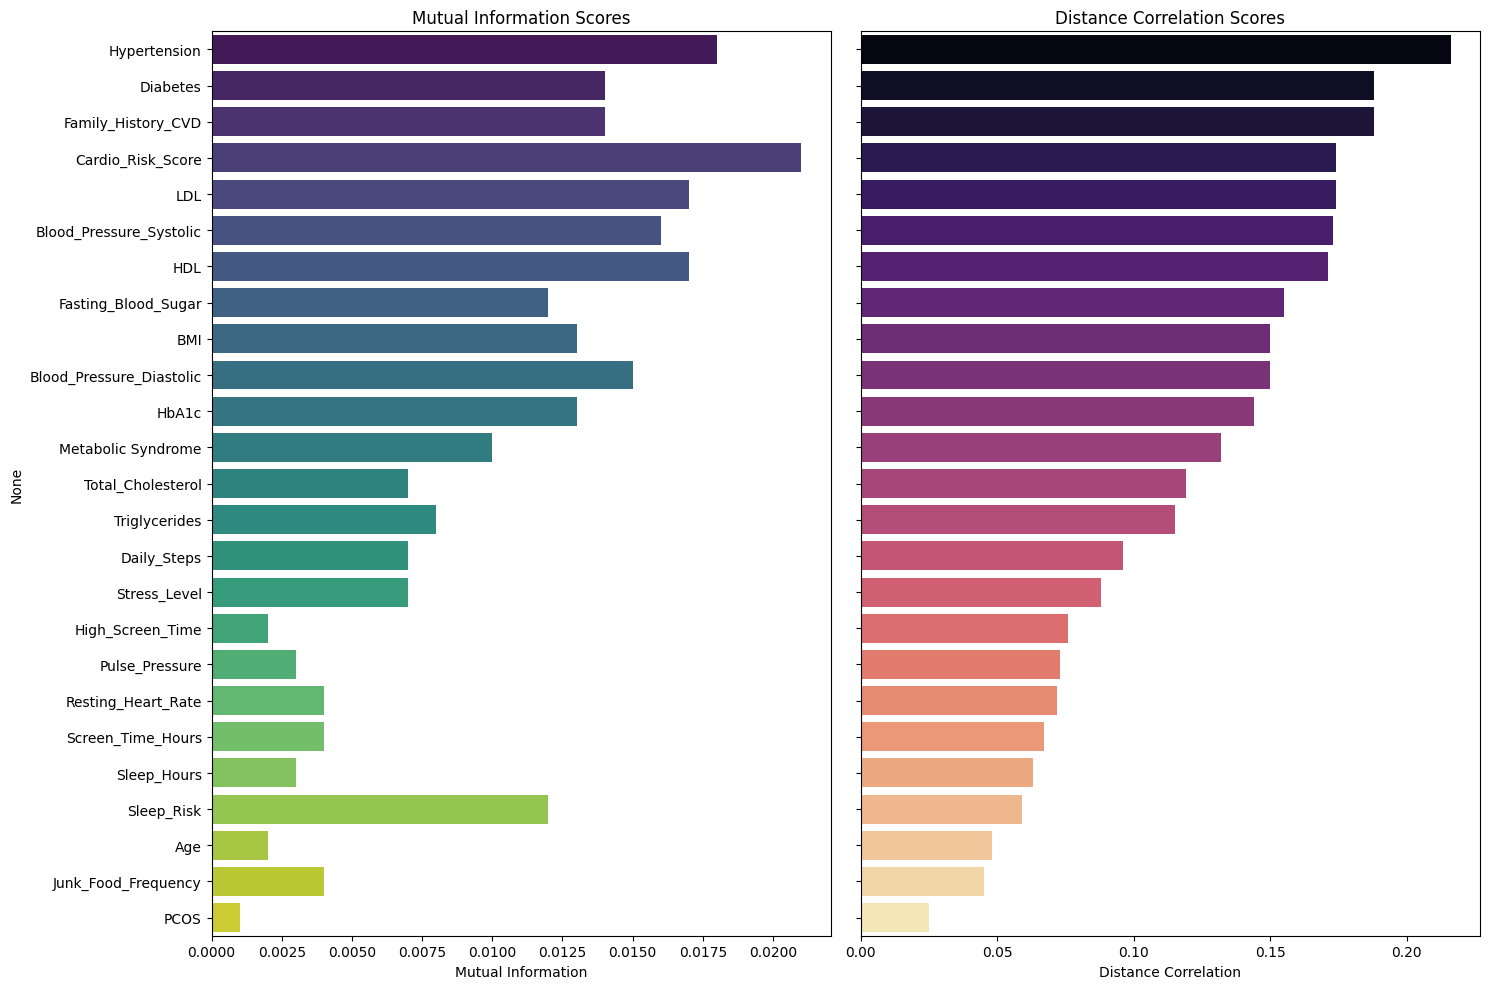

In [15]:
# name joblib file 
cor_file = 'cvd_feature_importance.joblib'

if os.path.exists(cor_file):
    comparison_df = joblib.load(cor_file)
    print("Loaded Successfully")

else:
    X_used = X_train.select_dtypes(include=['int64', 'float64']).copy()
    y_used = y_train.copy()
    
    # MUTUAL INFORMATION
    mi = mutual_info_classif(X_used, y_used, random_state=42)
    
    mi_scores = pd.Series(mi, index=X_used.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    
    # DISTANCE CORRELATION
    dcorr_scores = {}
    
    for col in X_used.columns:
        dcorr_scores[col] = dcor.distance_correlation(X_used[col], y_used)
    
    dcorr_series = pd.Series(dcorr_scores).sort_values(ascending=False)
    
    # COMBINE
    comparison_df = pd.DataFrame({
        'Mutual Information': mi_scores,
        'Distance Correlation': dcorr_series
    }).sort_values(by='Distance Correlation', ascending=False).round(3)
    
    # Save
    joblib.dump(comparison_df, cor_file)
    
    # VISUALIZATION 
    pd.set_option('display.max_rows', None)
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 10), sharey=True)
    
    sns.barplot(
        x=comparison_df['Mutual Information'],
        y=comparison_df.index,
        ax=axes[0],
        palette='viridis'
    )
    axes[0].set_title('Mutual Information Scores')
    
    sns.barplot(
        x=comparison_df['Distance Correlation'],
        y=comparison_df.index,
        ax=axes[1],
        palette='magma'
    )
    axes[1].set_title('Distance Correlation Scores')
    
    plt.tight_layout()
    plt.show()

# LOAD CASE 
fig, axes = plt.subplots(1, 2, figsize=(15, 10), sharey=True)

sns.barplot(
    x=comparison_df['Mutual Information'],
    y=comparison_df.index,
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title('Mutual Information Scores')

sns.barplot(
    x=comparison_df['Distance Correlation'],
    y=comparison_df.index,
    ax=axes[1],
    palette='magma'
)
axes[1].set_title('Distance Correlation Scores')

plt.tight_layout()
plt.show()

# 9. Encoding Categorical Data

In [16]:
# Encoding
ordinal_data = ['Smoking_Status', 'Socioeconomic_Status', 'Physical_Activity_Level', 'Air_Pollution_Exposure', 'Alcohol_Consumption']
nominal_data = ['Gender', 'Region', 'Diet_Type', 'Work_Stress_Type', 'Occupation']
binary_data = ['Urban_Rural']

# Ordinal Encoding
for col in ordinal_data:
    oe = OrdinalEncoder(categories=[list(X_train[col].unique())],
                       handle_unknown='use_encoded_value', unknown_value=-1)
    oe.fit(X_train[[col]])
    X_train[[col]] = oe.transform(X_train[[col]]).astype(int)
    X_valid[[col]] = oe.transform(X_valid[[col]]).astype(int)
    X_test[[col]] = oe.transform(X_test[[col]]).astype(int)

# OneHot Encoding on Nominal Data
ohe = OneHotEncoder(sparse_output = False, drop = 'first', handle_unknown = 'ignore')
ohe.fit(X_train[nominal_data])
def apply_ohe(Xd):
    enc = pd.DataFrame(ohe.transform(Xd[nominal_data]),
                      columns = ohe.get_feature_names_out(nominal_data), index = Xd.index)
    return pd.concat([Xd.drop(columns=nominal_data), enc], axis=1)

X_train = apply_ohe(X_train)
X_valid = apply_ohe(X_valid)
X_test = apply_ohe(X_test)

# Binary Encoding
binary_map = {'Urban':0, 'Rural':1}
for col in binary_data:
    X_train[col] = X_train[col].map(binary_map).fillna(0)
    X_valid[col] = X_valid[col].map(binary_map).fillna(0)
    X_test[col] = X_test[col].map(binary_map).fillna(0)

print(f'Final Features Count: {X_train.shape[1]}')

Final Features Count: 45


# 10. Hyperparameter Tuning
    Models: (RF + DT + XGBoost + LightGBM)
    First perform randomized search. after that perform grid search on the group created from randomized search. 

In [17]:
# File path for saving the tuned models
hpt_file = 'cvd_hpt_models.joblib'

# if os.path.exists(hpt_file):
#     best_rf, best_xgb, best_dt, best_lgbm = joblib.load(hpt_file)
#     print("Loaded pre-tuned models from storage.")
# else:
    # Define Stratified K-Fold
skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)
    
# RandomForest -> HPT
rf_model_parms = { 
    "n_estimators": list(range(100, 301, 100)),
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 8, 10, 12],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "max_features": ["sqrt", "log2"],
    "class_weight": ['balanced'],              # gives more importance to minority class in imbalanced data
    "min_impurity_decrease": [0.0, 0.001, 0.0001],
    "ccp_alpha": [0.0, 0.0001, 0.001],             # prunes trees to reduce overfitting (higher = simpler trees)
}          
rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42), 
    rf_model_parms, 
    verbose=True,                        # controls how much training progress gets printed
    n_iter=30,                           # Try only 50 random combinations
    cv=skf,      
    scoring='recall', 
    n_jobs=-1
)
rf_random.fit(X_train, y_train.values.ravel())
best_rf = rf_random.best_estimator_

# XGBoost -> HPT start time-02:13
xgb_model_parms = { 
    "n_estimators": list(range(200, 501, 100)),
    "max_depth": list(range(3, 11)),
    "learning_rate": [0.1, 0.01, 0.05, 0.2],
    "booster": ["gbtree"],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "reg_lambda": [1, 5, 10, 15],
    "scale_pos_weight": [144552 / 55448],
    "gamma": [0, 0.1, 0.3, 0.5],
}
xgb_random = RandomizedSearchCV( 
    XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        random_state=42,
        n_jobs=1 
    ),
    xgb_model_parms,
    n_iter=28,
    scoring='recall',
    cv=skf,
    verbose=2,
    n_jobs=-1,
    random_state=42
)
xgb_random.fit(X_train, y_train.values.ravel())
best_xgb = xgb_random.best_estimator_
  
# Decision Tree -> HPT 2:44
dt_model_parms = { 
    "criterion": ["gini", "entropy"],
    "splitter": ["best", "random"],
    "max_depth": [3, 5, 8, 10, 12],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "ccp_alpha": [0.0, 0.0001, 0.001, 0.01],
    "class_weight": [None, "balanced"]
}
dt_random = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_model_parms,
    n_iter=30, 
    cv=skf, 
    scoring='recall', 
    n_jobs=2
)
dt_random.fit(X_train, y_train.values.ravel())
best_dt = dt_random.best_estimator_

# LightGBM -> HPT
lgbm_model_parms = {
    "n_estimators": [200, 500, 800, 1000],
    "learning_rate": [0.01, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 6, 10],
    "min_child_samples": [20, 50, 100],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "scale_pos_weight": [144552 / 55448],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [0, 1, 5, 10],
    "min_child_weight": [1e-3, 1e-2, 1e-1]
}
lgbm_random = RandomizedSearchCV(
    LGBMClassifier(
        objective='binary',
        random_state=42,
        n_jobs=1 
    ),
    lgbm_model_parms,
    n_iter=26,
    scoring='recall',
    cv=skf,
    verbose=2,
    n_jobs=-1,
    random_state=42
)
lgbm_random.fit(X_train, y_train.values.ravel())
best_lgbm = lgbm_random.best_estimator_
    
# Save the best estimators to avoidre-running next time.
joblib.dump((best_rf, best_xgb, best_dt, best_lgbm), hpt_file)

# print('\n' + '*'*150 + '\n')
# print(f"RandomForest Best Params: {best_rf.get_params()}")
# print('\n' + '*'*150 + '\n')
# print(f"XGBoost Best Params:      {best_xgb.get_params()}")
# print('\n' + '*'*150 + '\n')
# print(f"DecisionTree Best Params: {best_dt.get_params()}")
# print('\n' + '*'*150 + '\n')
# print(f"LightGBM Best Params:     {best_lgbm.get_params()}")
# print('\n' + '*'*150 + '\n')

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Fitting 3 folds for each of 28 candidates, totalling 84 fits
Fitting 3 folds for each of 26 candidates, totalling 78 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 15224, number of negative: 114826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031139 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2318
[LightGBM] [Info] Number of data points in the train set: 130050, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.117063 -> initscore=-2.020545
[LightGBM] [Info] Start training from score -2.020545


['cvd_hpt_models.joblib']

## 10.1 removing class weights in order to use calculated "class_weights" values

In [18]:
# 1. Prepare your parameter dictionaries by removing the existing weight keys
rf_model_params = rf_random.best_params_.copy()
rf_model_params.pop('class_weight', None)

dt_model_params = dt_random.best_params_.copy()
dt_model_params.pop('class_weight', None)

xgb_model_params = xgb_random.best_params_.copy()
xgb_model_params.pop('scale_pos_weight', None)

lgbm_model_params = lgbm_random.best_params_.copy()
lgbm_model_params.pop('class_weight', None)
lgbm_model_params.pop('scale_pos_weight', None)

2.6069831193190014

# 11. Training Models based on HyperParameter Tuning

In [19]:
# file name where the models will be saved
hpt_training_file = 'cvd_hpt_trained_models.joblib'

# if os.path.exists(hpt_training_file):
#     rf_params, dt_params, xgb_params, lgbm_params = joblib.load(hpt_training_file)
#     print("Loaded pre-trained models from storage")

# else:
ratio = class_weights[1] / class_weights[0] # for XGBoost

best_models = {
    "RandomForest" : RandomForestClassifier(**rf_model_params, class_weight = class_weights,  random_state=42),
    "DecisionTree" : DecisionTreeClassifier(**dt_model_params, class_weight = class_weights, random_state=42),
    "XGBoost" : XGBClassifier(**xgb_model_params, scale_pos_weight = ratio, random_state=42),
    "LightGBM" : LGBMClassifier(**lgbm_model_params, class_weight = class_weights, random_state=42)
    }
        
for name, model in best_models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained on Hyperparameters & training data.")
  
joblib.dump(best_models, hpt_training_file)

RandomForest trained on Hyperparameters & training data.
DecisionTree trained on Hyperparameters & training data.
XGBoost trained on Hyperparameters & training data.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 15224, number of negative: 114826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.036654 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2318
[LightGBM] [Info] Number of data points in the train set: 130050, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514720 -> initscore=0.058897
[LightGBM] [Info] Start training from score 0.058897
LightGBM trained on Hyperparameters & training data.


['cvd_hpt_trained_models.joblib']

# 12. Probability Predictions on validation set

In [20]:
# Dictionary to store validation results
val_results = {}

for name, model in best_models.items():
    # Predict probabilities and classes
    y_val_prob = model.predict_proba(X_valid)[:, 1]  # for ROC-AUC and threshold tuning
    y_val_pred = (y_val_prob >= 0.236952).astype(int)
    
    # Metrics
    acc = accuracy_score(y_valid, y_val_pred)
    f1 = f1_score(y_valid, y_val_pred)
    recall = recall_score(y_valid, y_val_pred)
    roc_auc = roc_auc_score(y_valid, y_val_prob)
    f2 = fbeta_score(y_valid, y_val_pred, beta=2)


    # Store results
    val_results[name] = {
        "Accuracy": acc,
        "F1": f1,
        "F2": f2,
        "Recall": recall,
        "ROC-AUC": roc_auc
    }

    # Print detailed report
    print(f"\n{name} Validation Metrics:")
    print(classification_report(y_valid, y_val_pred))
    print(f"F2-Score: {f2:.3f}")
    print(f"ROC-AUC Score: {roc_auc:.4f}")


RandomForest Validation Metrics:
              precision    recall  f1-score   support

           0       0.98      0.16      0.27     20264
           1       0.13      0.98      0.23      2686

    accuracy                           0.25     22950
   macro avg       0.56      0.57      0.25     22950
weighted avg       0.88      0.25      0.26     22950

F2-Score: 0.432
ROC-AUC Score: 0.8178

DecisionTree Validation Metrics:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     20264
           1       0.12      1.00      0.21      2686

    accuracy                           0.12     22950
   macro avg       0.06      0.50      0.10     22950
weighted avg       0.01      0.12      0.02     22950

F2-Score: 0.399
ROC-AUC Score: 0.7156

XGBoost Validation Metrics:
              precision    recall  f1-score   support

           0       0.98      0.46      0.63     20264
           1       0.19      0.93      0.31      2686

    accur

# -> Finding Optimal Threshold for Best Recall

In [21]:
from sklearn.metrics import precision_recall_curve, fbeta_score
import numpy as np

# 1. Calculate precision and recall for various thresholds
precision, recall, thresholds = precision_recall_curve(y_valid, y_val_prob)

# 2. Calculate F2-score for each threshold
# Note: F2 = (5 * precision * recall) / (4 * precision + recall)
f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-10)

# 3. Find the threshold that maximizes F2
best_f2_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_f2_idx]

# 4. Generate the final predictions using the optimal threshold
y_val_pred = (y_val_prob >= best_threshold).astype(int)

print(f"Optimal Threshold for F2: {best_threshold:.6f}")

Optimal Threshold for F2: 0.485966


# 13. Threshold Tuning & Precision-Recall Curve
**Problem:** Default threshold of 0.5 is wrong for imbalanced data.  
**Fix:** Use Precision-Recall curve to find the threshold that maximises F1-Score.

Random Forest       — best threshold: 0.616  (was 0.5)  → best F1: 0.460
Decision Tree       — best threshold: 0.638  (was 0.5)  → best F1: 0.334
XGBoost             — best threshold: 0.445  (was 0.5)  → best F1: 0.497
LightGBM            — best threshold: 0.469  (was 0.5)  → best F1: 0.492


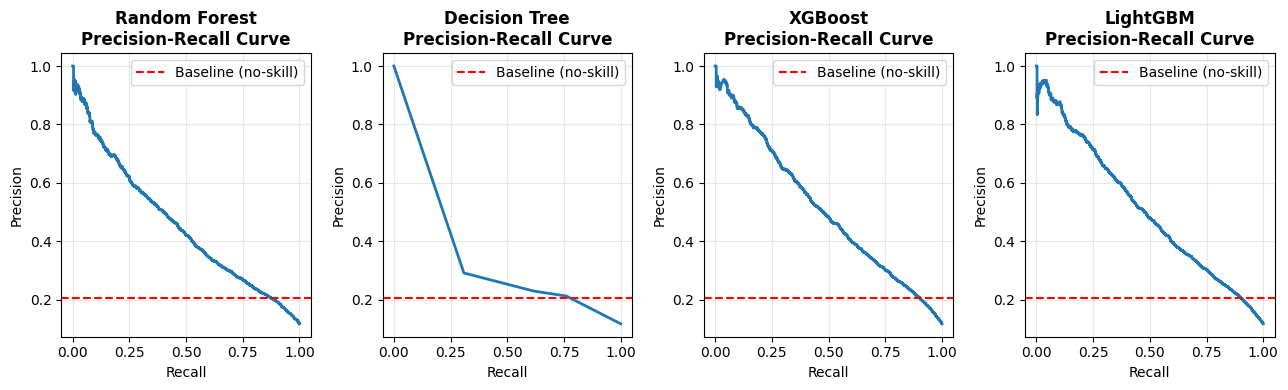

In [22]:
def find_best_threshold(model, X_val, y_val):
    """Find threshold that maximises F1 score."""
    y_prob = model.predict_proba(X_val)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    return best_threshold, f1_scores[best_idx], precisions, recalls, thresholds

# Find optimal thresholds using test set (in production, use a validation set)
rf_best_thr, rf_best_f1, rf_prec, rf_rec, rf_thrs = find_best_threshold(rf_random.best_estimator_, X_valid, y_valid)
dt_best_thr, dt_best_f1, dt_prec, dt_rec, dt_thrs = find_best_threshold(dt_random.best_estimator_, X_valid, y_valid)
xgb_best_thr, xgb_best_f1, xgb_prec, xgb_rec, xgb_thrs = find_best_threshold(xgb_random.best_estimator_, X_valid, y_valid)
lgbm_best_thr, lgbm_best_f1, lgbm_prec, lgbm_rec, lgbm_thrs = find_best_threshold(lgbm_random.best_estimator_, X_valid, y_valid)

print(f'Random Forest       — best threshold: {rf_best_thr:.3f}  (was 0.5)  → best F1: {rf_best_f1:.3f}')
print(f'Decision Tree       — best threshold: {dt_best_thr:.3f}  (was 0.5)  → best F1: {dt_best_f1:.3f}')
print(f'XGBoost             — best threshold: {xgb_best_thr:.3f}  (was 0.5)  → best F1: {xgb_best_f1:.3f}')
print(f'LightGBM            — best threshold: {lgbm_best_thr:.3f}  (was 0.5)  → best F1: {lgbm_best_f1:.3f}')

# Precision-Recall curve plot
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, (name, prec, rec, thrs, best_thr) in zip(axes, [
    ('Random Forest',       rf_prec, rf_rec, rf_thrs, rf_best_thr),
    ('Decision Tree',       dt_prec, dt_rec, dt_thrs, dt_best_thr),
    ('XGBoost',             xgb_prec, xgb_rec, xgb_thrs, xgb_best_thr),
    ('LightGBM',            lgbm_prec, lgbm_rec, lgbm_thrs, lgbm_best_thr)
]):
    ax.plot(rec, prec, lw=2)
    ax.axhline(0.2038, color='red', linestyle='--', label='Baseline (no-skill)')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{name}\nPrecision-Recall Curve', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 14. Voting Ensemble (All four models combined)

In [23]:
# joblib file name
vot_file = 'cvd_voting_ensemble.joblib'

# if os.path.exists(vot_file):
#     y_val_prob_ensemble = joblib.load(vot_file)
#     print("Done. from storage data.")
# else:
    # Build the ensemble
voting_model = VotingClassifier(
    estimators=[
        ('rf', best_models['RandomForest']),
        ('xgb', best_models['XGBoost']),
        ('lgbm', best_models['LightGBM']),
        ('dt', best_models['DecisionTree'])
    ],
    voting='soft'  # important: uses probabilities
)

# Train ensemble on training data
voting_model.fit(X_train, y_train)

# Probabilities for class 1 on validation set
y_val_prob_ensemble = voting_model.predict_proba(X_valid)[:, 1]

# saving as joblib file
joblib.dump(y_val_prob_ensemble, vot_file)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 15224, number of negative: 114826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.048835 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2318
[LightGBM] [Info] Number of data points in the train set: 130050, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514720 -> initscore=0.058897
[LightGBM] [Info] Start training from score 0.058897


['cvd_voting_ensemble.joblib']

# 15. Threshold Tuning on Ensemble Model

In [24]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score
import numpy as np

thresholds = np.arange(0.3, 0.8, 0.05)  # try different thresholds
best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    y_val_pred = (y_val_prob_ensemble > t).astype(int)
    f1 = f1_score(y_valid, y_val_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best threshold for ensemble:", best_threshold)

Best threshold for ensemble: 0.7


## 15.1 ROC Curve of all models 

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 15224, number of negative: 114826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018509 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2318
[LightGBM] [Info] Number of data points in the train set: 130050, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.117063 -> initscore=-2.020545
[LightGBM] [Info] Start training from score -2.020545


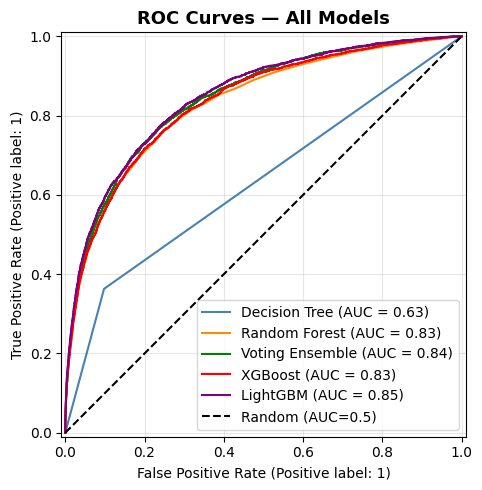

In [25]:
dt_model = DecisionTreeClassifier().fit(X_train, y_train)
rf_model = RandomForestClassifier().fit(X_train, y_train)
xgb_model = XGBClassifier().fit(X_train, y_train)
lgbm_model = LGBMClassifier().fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['steelblue', 'darkorange', 'green', 'red', 'purple']
for (name, model), color in zip([
    ('Decision Tree',       dt_model),
    ('Random Forest',       rf_model),
    ('Voting Ensemble',     voting_model),
    ('XGBoost',             xgb_model),
    ('LightGBM',            lgbm_model),
], colors):
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name, color=color)

ax.plot([0,1],[0,1],'k--', label='Random (AUC=0.5)')
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 16. Full Evaluation on all Models

In [26]:
def evaluate(name, model, X_te, y_te, threshold=0.5):
    y_prob = model.predict_proba(X_te)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    auc    = roc_auc_score(y_te, y_prob)
    return {
        'Model': name,
        'Threshold': threshold,
        'Accuracy':  round(accuracy_score(y_te, y_pred), 3),
        'Precision': round(precision_score(y_te, y_pred, zero_division=0), 3),
        'Recall':    round(recall_score(y_te, y_pred), 3),
        'F1':        round(f1_score(y_te, y_pred), 3),
        'AUC-ROC':   round(auc, 3),
    }, y_pred, y_prob
    
best_thresholds = {
    "RandomForest": rf_best_thr,
    "DecisionTree": dt_best_thr,
    "XGBoost": xgb_best_thr,
    "LightGBM": lgbm_best_thr
}

results = []
preds = {}

# ---------- INDIVIDUAL MODELS ----------
for name, model in best_models.items():
    
    # Default threshold
    r, yp, yprob = evaluate(f'{name} (0.5)', model, X_test, y_test, 0.5)
    results.append(r)
    
    # Tuned threshold (store your thresholds in a dict)
    if name in best_thresholds:
        thr = best_thresholds[name]
        r, yp, yprob = evaluate(f'{name} (tuned={thr:.2f})', model, X_test, y_test, thr)
        results.append(r)
        preds[f'{name} tuned'] = (yp, yprob)

# ---------- ENSEMBLE ----------
r, yp, yprob = evaluate(
    f'Ensemble (tuned={best_threshold:.2f})',
    voting_model,
    X_test,
    y_test,
    best_threshold
)

results.append(r)
preds['Ensemble'] = (yp, yprob)

# ---------- FINAL TABLE ----------
results_df = pd.DataFrame(results).set_index('Model')

print('\n📊 Full Model Comparison:')
display(results_df.sort_values('AUC-ROC', ascending=False))


📊 Full Model Comparison:


,Threshold,Accuracy,Precision,Recall,F1,AUC-ROC
Model,,,,,,
XGBoost (0.5),0.500000,0.774,0.309,0.758,0.439,0.849
XGBoost (tuned=0.44),0.444799,0.736,0.281,0.804,0.416,0.849
LightGBM (0.5),0.500000,0.774,0.310,0.756,0.439,0.849
LightGBM (tuned=0.47),0.469242,0.754,0.293,0.781,0.426,0.849
Ensemble (tuned=0.70),0.700000,0.884,0.503,0.491,0.497,0.843
RandomForest (0.5),0.500000,0.714,0.261,0.788,0.392,0.830
RandomForest (tuned=0.62),0.616105,0.853,0.408,0.565,0.474,0.830
DecisionTree (0.5),0.500000,0.646,0.219,0.789,0.343,0.729
DecisionTree (tuned=0.64),0.638096,0.713,0.233,0.634,0.341,0.729


# 17. Confusion Matrix

In [27]:
y_test.value_counts()

CVD_Risk
0    23840
1     3160
Name: count, dtype: int64

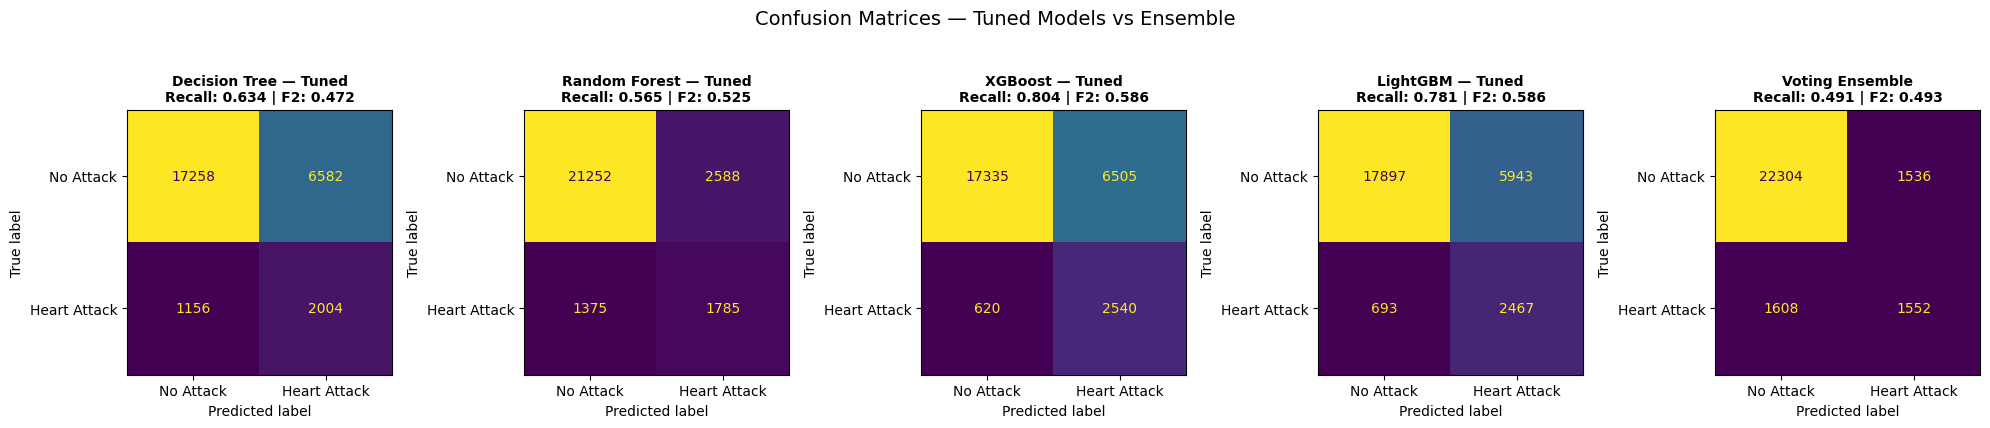


Goal for a medical predictor: high Recall (catch real cases) even if Precision drops.

TN (top-left)  = Correctly predicted NO  → Good  
FP (top-right) = Predicted YES, was NO   → False Alarm (acceptable)  
FN (bottom-left)= Predicted NO, was YES  → Dangerous Miss (minimize this!)  
TP (bottom-right)= Correctly predicted YES → Critical success  



In [28]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

labels = ['No Attack', 'Heart Attack']

plot_items = [
    ('DecisionTree tuned', 'Decision Tree — Tuned'),
    ('RandomForest tuned', 'Random Forest — Tuned'),
    ('XGBoost tuned', 'XGBoost — Tuned'),
    ('LightGBM tuned', 'LightGBM — Tuned'),
    ('Ensemble', 'Voting Ensemble')
]

# threshold = 0.3

for ax, (key, title) in zip(axes, plot_items):
    y_prob_here = preds[key][1]
    y_pred_here = preds[key][1]   # (y_pred, y_prob)
    y_pred_here = preds[key][0]   # (y_pred, y_prob)
    # y_pred_tuned = (y_prob_here >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_here)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )
    
    disp.plot(ax=ax, colorbar=False)

     # Calculate and display tuned metrics
    from sklearn.metrics import recall_score, fbeta_score
    r_score = recall_score(y_test, y_pred_here)
    f2_score = fbeta_score(y_test, y_pred_here, beta=2.000)
    ax.set_title(f"{title}\nRecall: {r_score:.3f} | F2: {f2_score:.3f}", fontweight='bold', fontsize=10)


plt.suptitle('Confusion Matrices — Tuned Models vs Ensemble', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

print('''
Goal for a medical predictor: high Recall (catch real cases) even if Precision drops.

TN (top-left)  = Correctly predicted NO  → Good  
FP (top-right) = Predicted YES, was NO   → False Alarm (acceptable)  
FN (bottom-left)= Predicted NO, was YES  → Dangerous Miss (minimize this!)  
TP (bottom-right)= Correctly predicted YES → Critical success  
''')

In [29]:
from sklearn.ensemble import VotingClassifier

# List your 5 trained models
ensemble_model =  VotingClassifier(
    estimators=[
        ('rf', best_models['RandomForest']),
        ('xgb', best_models['XGBoost']),
        ('lgbm', best_models['LightGBM']),
        ('dt', best_models['DecisionTree']),
        ('vt', voting_model)
    ],
    voting='soft'  # important: uses probabilities
)

# Fit the ensemble (or use already fitted models if supported)
ensemble_model.fit(X_train, y_train)

# # Save the ensemble
# with open('ensemble_model.pkl', 'wb') as file:
#     pickle.dump(ensemble_model, file)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 15224, number of negative: 114826
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059710 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2318
[LightGBM] [Info] Number of data points in the train set: 130050, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.514720 -> initscore=0.058897
[LightGBM] [Info] Start training from score 0.058897
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 15224, number of negative: 114826
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014210 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2318
[LightGBM] [In

,estimators,"[('rf', ...), ('xgb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,n_estimators,100
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,3


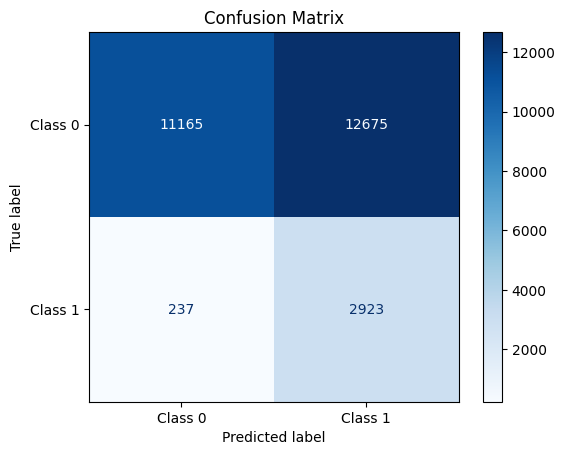

In [30]:
y_probs = ensemble_model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs > 0.3).astype(int) #initial=0.3

# 2. Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_custom)

# 3. Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()

In [31]:
y_probs = ensemble_model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs > 0.3).astype(int)

# 2. Calculate individual metrics
accuracy = accuracy_score(y_test, y_pred_custom)
precision = precision_score(y_test, y_pred_custom)
recall = recall_score(y_test, y_pred_custom)
roc_auc = roc_auc_score(y_test, y_probs) # Use probabilities here

print(f"Metrics at 0.3 threshold:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# 3. Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom))

Metrics at 0.3 threshold:
Accuracy:  0.5218
Precision: 0.1874
Recall:    0.9250
ROC-AUC:   0.8431

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.47      0.63     23840
           1       0.19      0.93      0.31      3160

    accuracy                           0.52     27000
   macro avg       0.58      0.70      0.47     27000
weighted avg       0.89      0.52      0.60     27000



In [32]:
# 1. Get probabilities from your ensemble model
y_probs = ensemble_model.predict_proba(X_test)[:, 1]

# 2. Define a range of thresholds to test
thresholds = np.linspace(0.1, 0.9, 81) # Tests from 0.1 to 0.9 in steps of 0.01

best_f1 = 0
best_threshold = 0

# 3. Find the threshold that yields the highest F1-Score
for t in thresholds:
    y_pred = (y_probs > t).astype(int)
    score = f1_score(y_test, y_pred)
    if score > best_f1:
        best_f1 = score
        best_threshold = t

print(f"Optimal Threshold (by F1-Score): {best_threshold:.6f}")
print(f"Best F1-Score: {best_f1:.4f}")

Optimal Threshold (by F1-Score): 0.680000
Best F1-Score: 0.5001


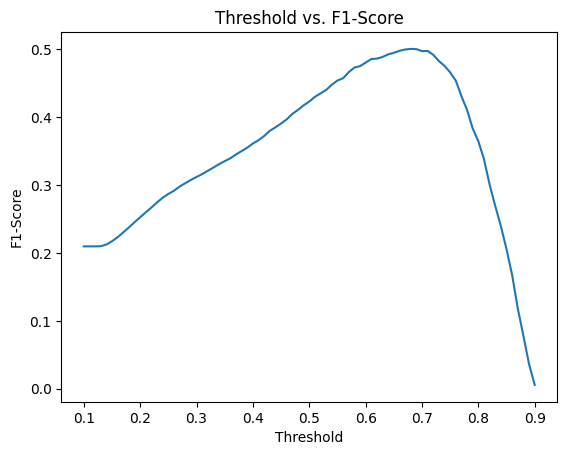

In [33]:
import matplotlib.pyplot as plt

f1_scores = [f1_score(y_test, (y_probs > t).astype(int)) for t in thresholds]
plt.plot(thresholds, f1_scores)
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.title('Threshold vs. F1-Score')
plt.show()

In [34]:
# Map your specific thresholds as identified in your notebook
final_thresholds = {
    "RandomForest": 0.620683,
    "DecisionTree": 0.620683,
    "XGBoost": 0.444799,
    "LightGBM": 0.469242,
    "Ensemble": 0.70000,  # From your 'Ensemble (tuned=0.70)' entry
    "Ensemble2": 0.68000
}

In [35]:
class ThresholdModel:
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold
        
    def predict(self, X):
        # Assumes the model has a predict_proba method
        probs = self.model.predict_proba(X)[:, 1]
        return (probs > self.threshold).astype(int)
    
    def predict_proba(self, X):
        return self.model.predict_proba(X)

In [36]:
import pickle

# 1. Map your models to their names and thresholds
# Ensure 'voting_model' is defined from your ensemble step
production_models = {
    'tuned_rf.pkl': (best_models['RandomForest'], final_thresholds['RandomForest']),
    'tuned_dt.pkl': (best_models['DecisionTree'], final_thresholds['DecisionTree']),
    'tuned_xgb.pkl': (best_models['XGBoost'], final_thresholds['XGBoost']),
    'tuned_lgbm.pkl': (best_models['LightGBM'], final_thresholds['LightGBM']),
    'tuned_ensemble.pkl': (voting_model, final_thresholds['Ensemble']),
    'tuned_ensemble2.pkl': (ensemble_model, final_thresholds['Ensemble2'])
}

# 2. Wrap and save in one go
for filename, (model_obj, thr) in production_models.items():
    # Wrap the tuned model with its specific threshold
    tuned_model = ThresholdModel(model_obj, threshold=thr)
    
    # Save the wrapper (which contains the tuned model AND the threshold)
    with open(filename, 'wb') as file:
        pickle.dump(tuned_model, file)
    
    print(f"Saved {filename} (Threshold: {thr})")

Saved tuned_rf.pkl (Threshold: 0.620683)
Saved tuned_dt.pkl (Threshold: 0.620683)
Saved tuned_xgb.pkl (Threshold: 0.444799)
Saved tuned_lgbm.pkl (Threshold: 0.469242)
Saved tuned_ensemble.pkl (Threshold: 0.7)
Saved tuned_ensemble2.pkl (Threshold: 0.68)
